# Consolidação SL × LFR × TF-C — DAGHAR / HAR

Notebook **somente de leitura/visualização**. Lê os três caches de avaliação
(`results/supervised_eval_transfer.csv`, `results/ssl_lfr_eval_transfer.csv`,
`results/ssl_tfc_eval_transfer.csv`) e compara os **métodos entre si** nos
mesmos eixos: 4 encoders × matriz de transfer 7×6 × 2 protocolos (`linear`,
`finetune`) × 4 regimes de dados (1/10/100 amostras-por-classe e 100%).

As análises aprofundadas de cada método (matrizes de transfer, comb→target,
inversão especialista↔combinado) ficam nos notebooks dedicados
`ssl_lfr_avaliation.ipynb` e `ssl_tfc_avaliation.ipynb`; aqui só entra o que
contrasta SL / LFR / TF-C.

Cenários (mesma taxonomia dos outros notebooks):

- **Especialista (in-domain)**: `source == target`.
- **Generalista (combinado)**: `source == combined`.
- **Transfer out-domain**: `source ∈ datasets, source != target`.

Estrutura: **1.** setup · **2.** cargas e cobertura · **3.** data-efficiency
dos 3 métodos · **4.** tabela-resumo por cenário/regime · **5.** barras por
cenário · **6.** Δ(TF-C − LFR) por dataset · **7.** transfer out-domain
método a método · **8.** placar (melhor método por célula) · **9.** conclusões.

## 1. Setup

In [1]:
import sys
from pathlib import Path

_p = Path.cwd()
PROJECT_ROOT = None
while _p != _p.parent:
    if (_p / "minerva").is_dir() and (_p / "scripts").is_dir():
        PROJECT_ROOT = _p
        break
    _p = _p.parent
if PROJECT_ROOT is None:
    raise RuntimeError(f"Raiz do projeto não encontrada a partir de {Path.cwd()}")

for p in (PROJECT_ROOT, PROJECT_ROOT / "scripts"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = /home/miguel.barreto/fed-har


In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from common import DATASETS, COMBINED_DATASET_NAME

warnings.filterwarnings("ignore")
sns.set_context("notebook")

ENCODERS = ["resnetse5", "cnnpff", "rnn", "tstcc"]
ENCODER_PRETTY = {"resnetse5": "ResNet-SE-5", "cnnpff": "CNN-PFF", "rnn": "RNN (BiGRU)",
                  "tstcc": "TS-TCC Enc"}
COMBINED = COMBINED_DATASET_NAME
PROTOCOLS = ["linear", "finetune"]
PROTOCOL_PRETTY = {"linear": "Linear readout", "finetune": "Full finetuning"}

SHOT_ORDER = ["1", "10", "100", "full"]
SHOT_LABELS = {"1": "1", "10": "10", "100": "100", "full": "100%"}

# Métodos SSL comparados (slug do cache -> rótulo) e cores fixas por método.
SSL_METHODS = {"lfr": "LFR", "tfc": "TF-C"}
METHOD_COLORS = {"SL": "#0173B2", "LFR": "#DE8F05", "TF-C": "#029E73"}
PROTOCOL_LINESTYLE = {"finetune": "-", "linear": "--"}

RESULTS_DIR = PROJECT_ROOT / "results"
SUP_CACHE = RESULTS_DIR / "supervised_eval_transfer.csv"
SSL_CACHES = {m: RESULTS_DIR / f"ssl_{m}_eval_transfer.csv" for m in SSL_METHODS}
print("SL  cache:", SUP_CACHE)
for m, p in SSL_CACHES.items():
    print(f"{SSL_METHODS[m]:4s} cache:", p)

SL  cache: /home/miguel.barreto/fed-har/results/supervised_eval_transfer.csv
LFR  cache: /home/miguel.barreto/fed-har/results/ssl_lfr_eval_transfer.csv
TF-C cache: /home/miguel.barreto/fed-har/results/ssl_tfc_eval_transfer.csv


## 2. Cargas dos caches e cobertura

Todos os caches são apenas lidos (gerados por `scripts/ssl/pretrain_{lfr,tfc}.py`
+ `scripts/ssl/downstream_eval.py` e `scripts/eval_transfer.py`). Os três
DataFrames são empilhados num único `df` com a coluna `method` ∈
{`SL`, `LFR`, `TF-C`}; para o SL, `protocol` recebe o marcador `"sl"` (o
baseline não tem a distinção linear/finetune).

In [3]:
COLS = ["method", "encoder", "source", "seed", "protocol", "n_shots",
        "target", "test_acc", "test_f1_macro"]


def _load(path, method, protocol_backfill=None):
    if not path.exists():
        print(f"[aviso] cache ausente: {path.name} — rode os scripts correspondentes.")
        return pd.DataFrame(columns=COLS)
    d = pd.read_csv(path)
    d["method"] = method
    if protocol_backfill is not None and "protocol" not in d.columns:
        d["protocol"] = protocol_backfill
    if "n_shots" not in d.columns:
        d["n_shots"] = "full"
    d["n_shots"] = d["n_shots"].fillna("full").astype(str)
    d["test_acc"] = pd.to_numeric(d["test_acc"], errors="coerce")
    d["test_f1_macro"] = pd.to_numeric(d["test_f1_macro"], errors="coerce")
    return d[COLS]


df = pd.concat(
    [_load(SUP_CACHE, "SL", protocol_backfill="sl")]
    + [_load(SSL_CACHES[m], SSL_METHODS[m]) for m in SSL_METHODS],
    ignore_index=True)

cov = (df.groupby(["method", "protocol"])
         .agg(linhas=("test_acc", "size"),
              encoders=("encoder", "nunique"),
              fontes=("source", "nunique"),
              seeds=("seed", "nunique"),
              regimes=("n_shots", "nunique")))
display(cov)

linhas  encoders  fontes  seeds  regimes
method protocol                                          
LFR    finetune    2688         4       7      4        4
       linear      2688         4       7      4        4
SL     sl          2688         4       7      4        4
TF-C   finetune    2688         4       7      4        4
       linear      2688         4       7      4        4

## 3. Data-efficiency — os 3 métodos ao longo dos regimes

Curvas de acurácia vs. nº de rótulos por classe, um painel por encoder.
Cor = método (SL azul, LFR laranja, TF-C verde); traço cheio = finetune,
tracejado = linear readout. Duas visões: **in-domain** (`source == target`)
e **transfer out-domain** (`source ∈ datasets, source ≠ target`).

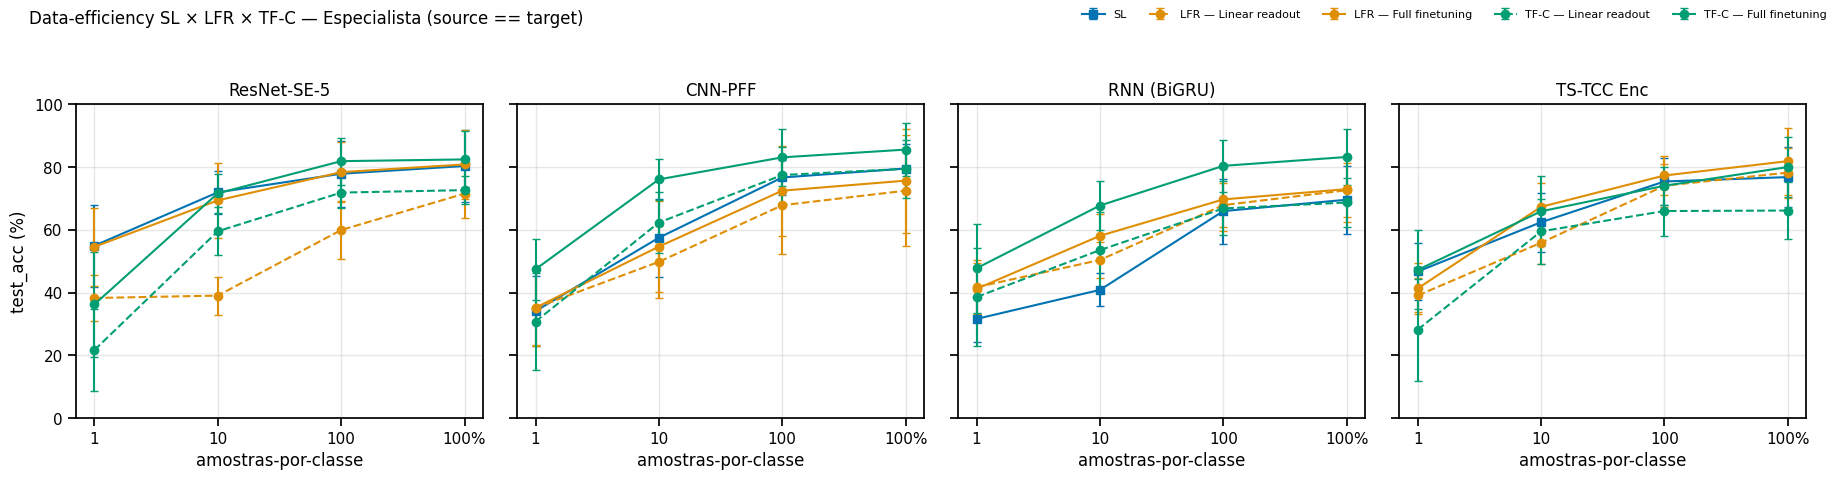

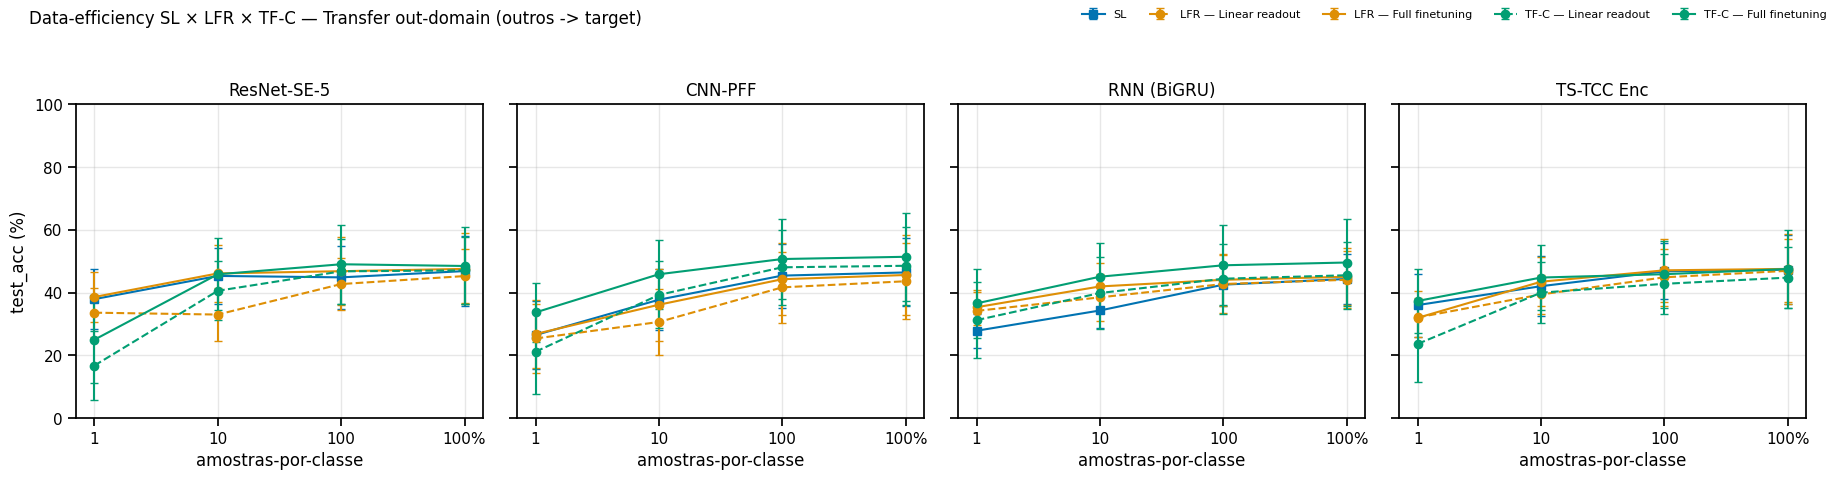

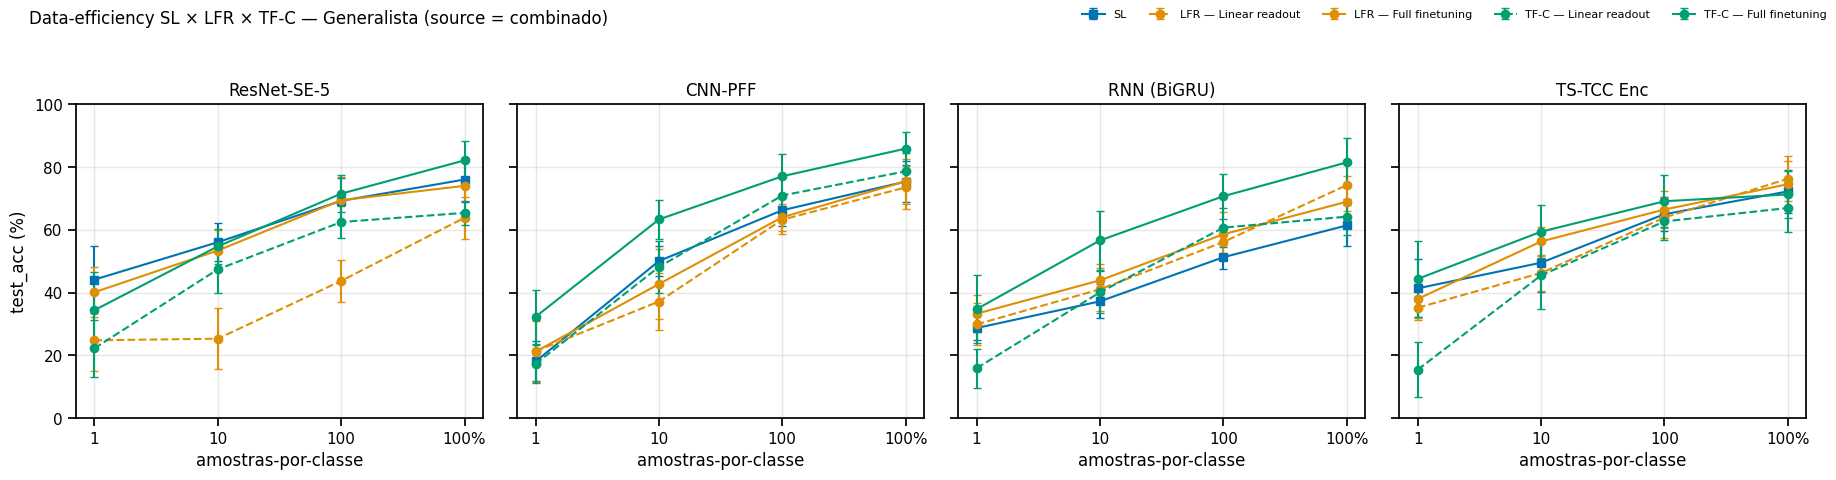

In [4]:
def scenario_slice(d, scenario):
    """Filtra um dos 3 cenários ('esp' | 'comb' | 'transf')."""
    if scenario == "esp":
        return d[d.source == d.target]
    if scenario == "comb":
        return d[d.source == COMBINED]
    return d[(d.source.isin(DATASETS)) & (d.source != d.target)]


SCENARIOS = [
    ("esp",    "Especialista (source == target)"),
    ("comb",   "Generalista (source = combinado)"),
    ("transf", "Transfer out-domain (outros -> target)"),
]
SCENARIO_PRETTY = dict(SCENARIOS)

# Séries método×protocolo usadas nas comparações (SL não tem protocolo).
SERIES = [("SL", "sl"), ("LFR", "linear"), ("LFR", "finetune"),
          ("TF-C", "linear"), ("TF-C", "finetune")]


def _series_label(method, proto):
    return method if proto == "sl" else f"{method} — {PROTOCOL_PRETTY[proto]}"


def _curve(d, metric="test_acc"):
    xs, ms, ss = [], [], []
    for i, shots in enumerate(SHOT_ORDER):
        v = d[d.n_shots == shots][metric].dropna()
        if v.empty:
            continue
        xs.append(i); ms.append(v.mean() * 100); ss.append(v.std() * 100)
    return xs, ms, ss


def plot_data_efficiency(scenario="esp", metric="test_acc"):
    fig, axes = plt.subplots(1, len(ENCODERS), figsize=(4.6 * len(ENCODERS), 4.6),
                             sharey=True)
    for c, encoder in enumerate(ENCODERS):
        ax = axes[c]
        for method, proto in SERIES:
            d = df[(df.method == method) & (df.protocol == proto)
                   & (df.encoder == encoder)]
            xs, m, s = _curve(scenario_slice(d, scenario), metric)
            if not xs:
                continue
            ax.errorbar(xs, m, yerr=s, capsize=3,
                        marker="s" if method == "SL" else "o",
                        linestyle="-" if proto == "sl" else PROTOCOL_LINESTYLE[proto],
                        color=METHOD_COLORS[method],
                        label=_series_label(method, proto) if c == 0 else None)
        ax.set_xticks(range(len(SHOT_ORDER)))
        ax.set_xticklabels([SHOT_LABELS[s] for s in SHOT_ORDER])
        ax.set_xlabel("amostras-por-classe")
        ax.set_title(ENCODER_PRETTY[encoder])
        ax.set_ylim(0, 100); ax.grid(alpha=0.3); ax.set_axisbelow(True)
        if c == 0:
            ax.set_ylabel(f"{metric} (%)")
    fig.legend(loc="upper right", ncols=5, fontsize=8, frameon=False)
    fig.suptitle(f"Data-efficiency SL × LFR × TF-C — {SCENARIO_PRETTY[scenario]}",
                 x=0.02, ha="left", y=1.04, fontsize=12)
    plt.tight_layout(); plt.show()


plot_data_efficiency("esp")
plot_data_efficiency("transf")
plot_data_efficiency("comb")

## 4. Tabela-resumo — média por método × cenário × regime

Acurácia média (sobre encoders, alvos e seeds) das 5 séries em cada cenário e
regime, com o Δ em pp contra o baseline SL do mesmo cenário/regime. Visão
compacta de "quem ganha onde" antes das figuras caso a caso.

In [5]:
def summary_table(metric="test_acc"):
    rows = []
    for scen, _ in SCENARIOS:
        for shots in SHOT_ORDER:
            base = None
            for method, proto in SERIES:
                d = scenario_slice(df[(df.method == method) & (df.protocol == proto)], scen)
                v = d[d.n_shots == shots][metric].dropna()
                if v.empty:
                    continue
                acc = v.mean() * 100
                if method == "SL":
                    base = acc
                rows.append({"cenário": SCENARIO_PRETTY[scen],
                             "regime": SHOT_LABELS[shots],
                             "série": _series_label(method, proto),
                             f"{metric} (%)": acc,
                             "Δ vs SL (pp)": np.nan if base is None else acc - base})
    t = pd.DataFrame(rows)
    return (t.pivot_table(index=["cenário", "regime"], columns="série",
                          values=[f"{metric} (%)", "Δ vs SL (pp)"], sort=False)
             .round(1))


display(summary_table("test_acc"))

test_acc (%)  \
série                                                   SL   
cenário                                regime                
Especialista (source == target)        1              41.9   
                                       10             58.2   
                                       100            74.0   
                                       100%           76.6   
Generalista (source = combinado)       1              33.1   
                                       10             48.2   
                                       100            63.0   
                                       100%           71.3   
Transfer out-domain (outros -> target) 1              32.1   
                                       10             39.9   
                                       100            44.9   
                                       100%           46.3   

                                                                    \
série                                         LFR — Linear readout   
cenário                                regime                        
Especialista (source == target)        1                      38.6   
                                       10                     48.8   
                                       100                    67.4   
                                       100%                   73.7   
Generalista (source = combinado)       1                      27.8   
                                       10                     37.5   
                                       100                    56.8   
                                       100%                   72.0   
Transfer out-domain (outros -> target) 1                      31.3   
                                       10                     35.4   
                                       100                    43.0   
                                       100%                   45.0   

                                                                     \
série                                         LFR — Full finetuning   
cenário                                regime                         
Especialista (source == target)        1                       43.1   
                                       10                      62.4   
                                       100                     74.5   
                                       100%                    77.9   
Generalista (source = combinado)       1                       33.2   
                                       10                      49.1   
                                       100                     64.6   
                                       100%                    73.3   
Transfer out-domain (outros -> target) 1                       33.2   
                                       10                      41.9   
                                       100                     45.6   
                                       100%                    46.5   

                                                                     \
série                                         TF-C — Linear readout   
cenário                                regime                         
Especialista (source == target)        1                       29.8   
                                       10                      58.8   
                                       100                     70.6   
                                       100%                    71.8   
Generalista (source = combinado)       1                       17.8   
                                       10                      45.3   
                                       100                     64.2   
                                       100%                    68.8   
Transfer out-domain (outros -> target) 1                       23.2   
                                       10                      39.9   
                                       100                     45.5   
    

## 5. Barras por cenário — Especialista × Combinado × Transfer

Grade cenário (linhas) × encoder (colunas) com as 5 séries por regime. Barra
de erro = desvio-padrão entre seeds (da média por seed).

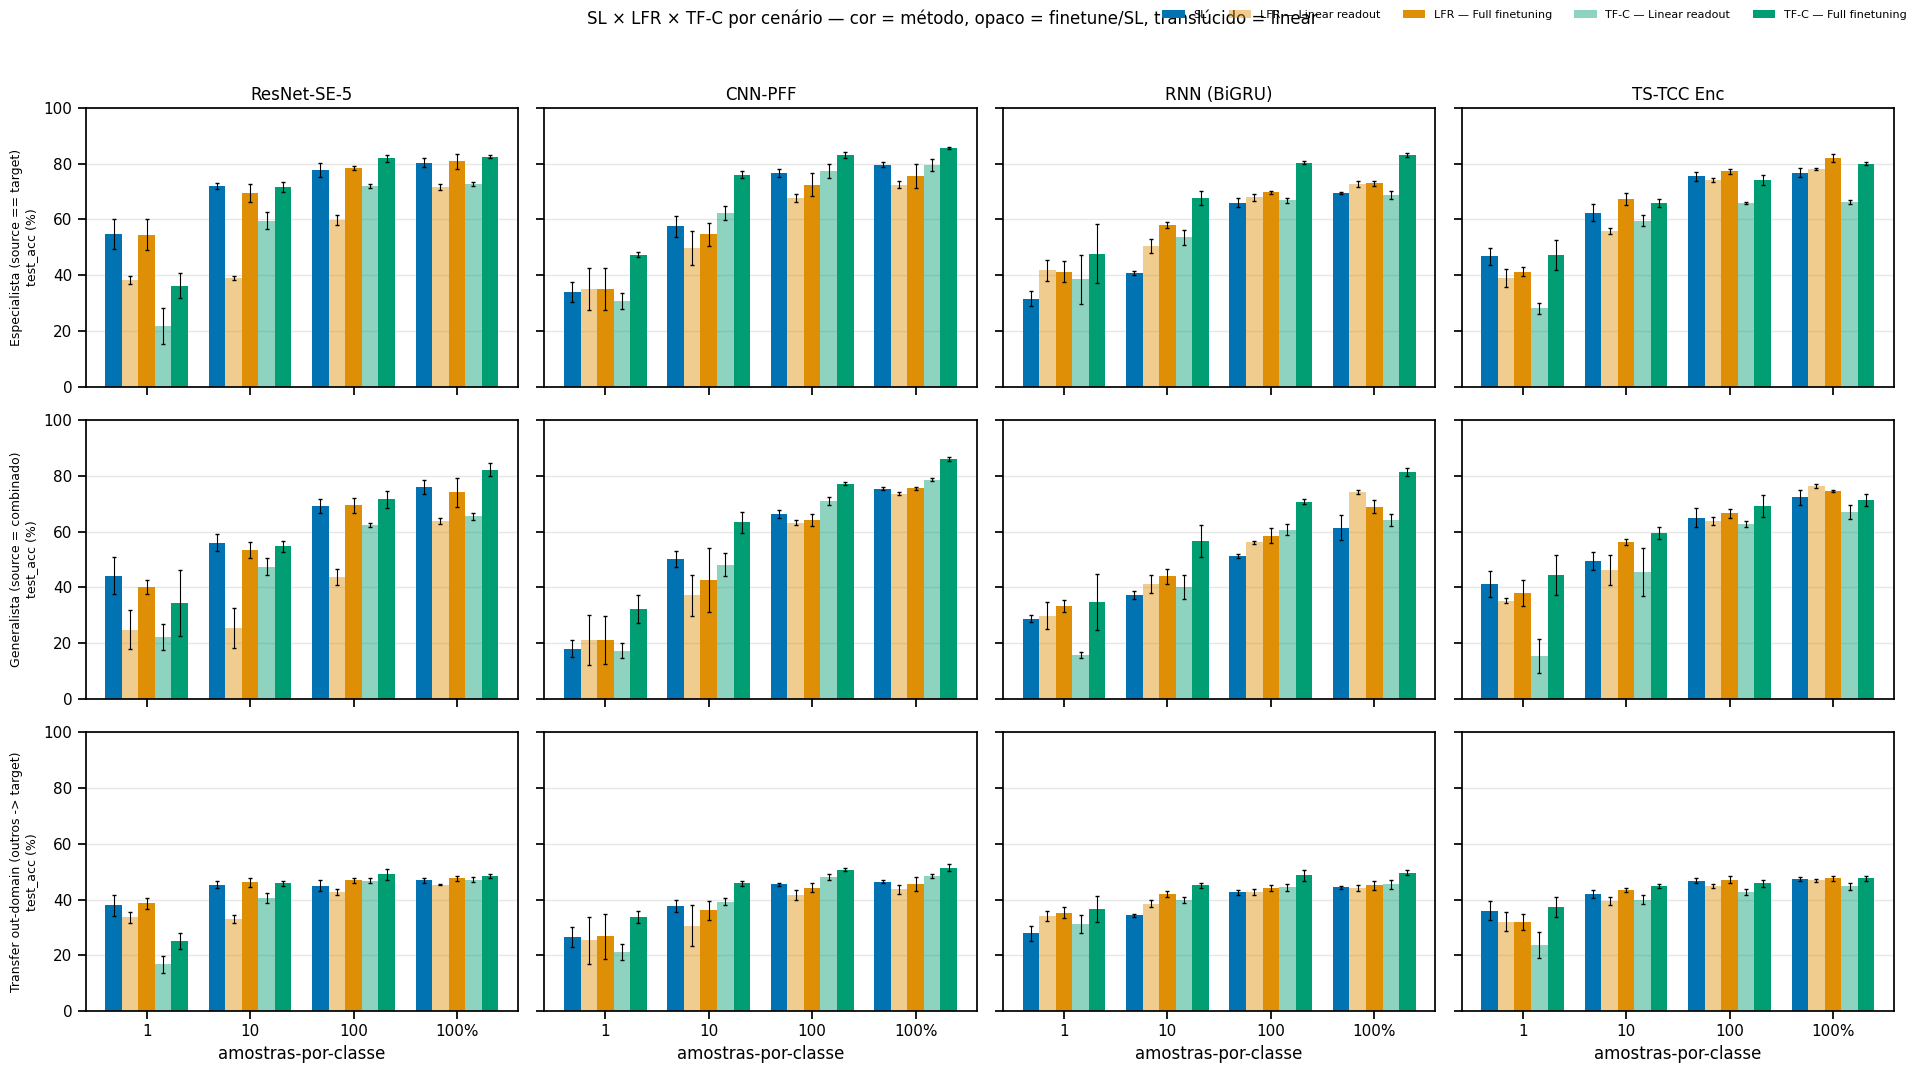

In [6]:
def bars_by_scenario(metric="test_acc"):
    fig, axes = plt.subplots(3, len(ENCODERS), figsize=(4.8 * len(ENCODERS), 10.5),
                             sharex=True, sharey=True)
    width = 0.16
    x = np.arange(len(SHOT_ORDER))
    for r, (scen, scen_title) in enumerate(SCENARIOS):
        for c, encoder in enumerate(ENCODERS):
            ax = axes[r, c]
            for k, (method, proto) in enumerate(SERIES):
                d = scenario_slice(df[(df.method == method) & (df.protocol == proto)
                                      & (df.encoder == encoder)], scen)
                means = [d[d.n_shots == s][metric].mean() * 100 for s in SHOT_ORDER]
                stds = [d[d.n_shots == s].groupby("seed")[metric].mean().std() * 100
                        for s in SHOT_ORDER]
                ax.bar(x + (k - 2) * width, means, width, yerr=stds, capsize=1.5,
                       color=METHOD_COLORS[method],
                       alpha=1.0 if proto in ("sl", "finetune") else 0.45,
                       error_kw={"elinewidth": 0.8},
                       label=_series_label(method, proto) if (r == 0 and c == 0) else None)
            if r == 0:
                ax.set_title(ENCODER_PRETTY[encoder])
            if c == 0:
                ax.set_ylabel(f"{scen_title}\n{metric} (%)", fontsize=9)
            if r == 2:
                ax.set_xlabel("amostras-por-classe")
            ax.set_xticks(x); ax.set_xticklabels([SHOT_LABELS[s] for s in SHOT_ORDER])
            ax.set_ylim(0, 100); ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)
    fig.legend(loc="upper right", ncols=5, fontsize=8, frameon=False)
    fig.suptitle("SL × LFR × TF-C por cenário — cor = método, opaco = finetune/SL, "
                 "translúcido = linear", y=1.02, fontsize=12)
    plt.tight_layout(); plt.show()


bars_by_scenario()

## 6. Δ(TF-C − LFR) caso a caso, por dataset

Contraste direto entre os dois métodos SSL (mesmo protocolo, mesmo regime,
mesmo encoder): heatmap dataset-alvo × regime, um painel por encoder, azul =
TF-C melhor. Responde *onde* a escolha do método de pré-treino importa.

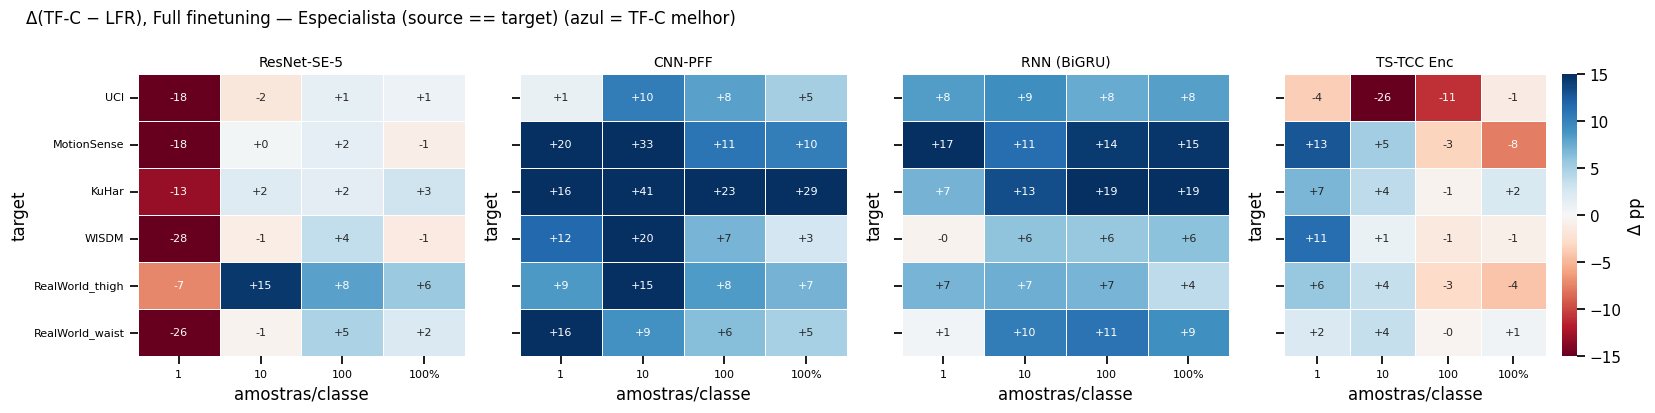

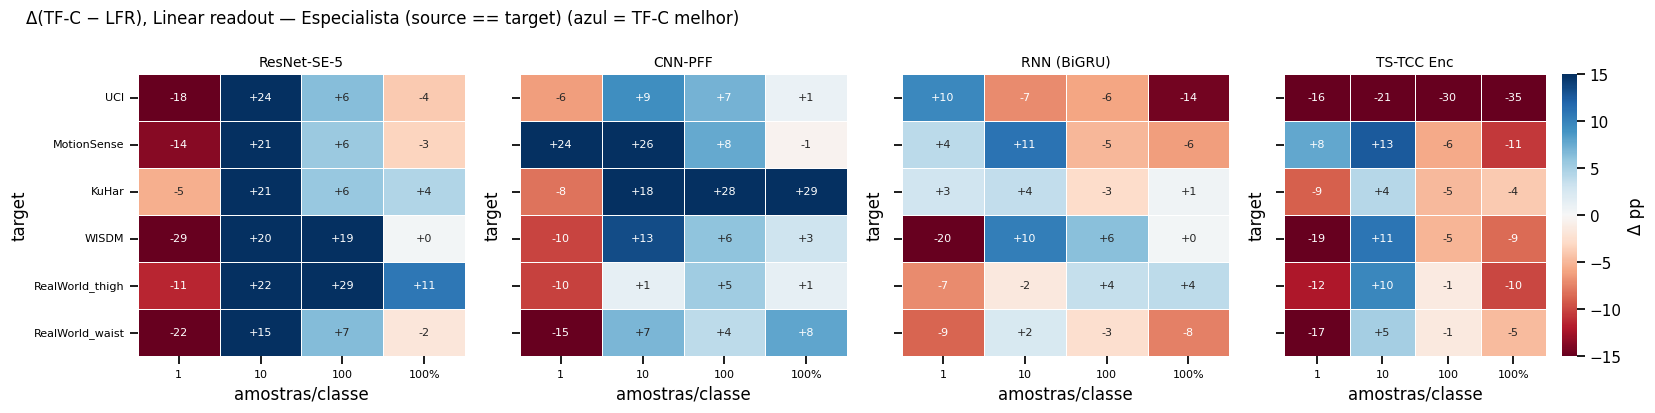

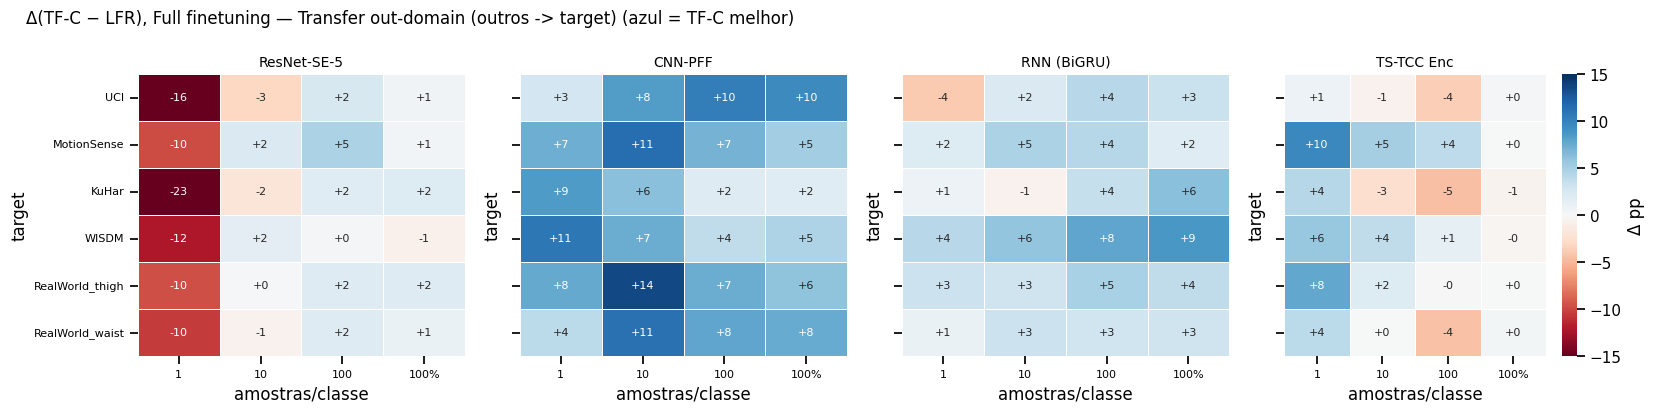

In [7]:
def delta_ssl_heatmap(scenario="esp", protocol="finetune", metric="test_acc", vmax=15):
    fig, axes = plt.subplots(1, len(ENCODERS), figsize=(4.2 * len(ENCODERS), 4.2))
    for c, encoder in enumerate(ENCODERS):
        ax = axes[c]
        def _m(method):
            d = scenario_slice(df[(df.method == method) & (df.protocol == protocol)
                                  & (df.encoder == encoder)], scenario)
            return d.groupby(["target", "n_shots"])[metric].mean()
        delta = ((_m("TF-C") - _m("LFR")) * 100).unstack().reindex(
            index=DATASETS, columns=SHOT_ORDER)
        delta.columns = [SHOT_LABELS[s] for s in SHOT_ORDER]
        sns.heatmap(delta, annot=True, fmt="+.0f", cmap="RdBu", center=0,
                    vmin=-vmax, vmax=vmax, ax=ax, linewidths=0.5,
                    cbar=(c == len(ENCODERS) - 1), cbar_kws={"label": "Δ pp"},
                    annot_kws={"fontsize": 8})
        ax.set_title(ENCODER_PRETTY[encoder], fontsize=10)
        ax.set_yticklabels(ax.get_yticklabels() if c == 0 else [], fontsize=8, rotation=0)
        ax.set_xlabel("amostras/classe"); ax.tick_params(labelsize=8)
    fig.suptitle(f"Δ(TF-C − LFR), {PROTOCOL_PRETTY[protocol]} — "
                 f"{SCENARIO_PRETTY[scenario]} (azul = TF-C melhor)",
                 x=0.02, ha="left", fontsize=12)
    plt.tight_layout(); plt.show()


delta_ssl_heatmap("esp", "finetune")
delta_ssl_heatmap("esp", "linear")
delta_ssl_heatmap("transf", "finetune")

## 7. Transfer out-domain método a método

O transfer cross-domínio é a motivação da parte federada. Barras da acurácia
média de transfer (todas as fontes ≠ alvo) por alvo, encoder e método —
finetune, nos regimes 10-shot e 100%.

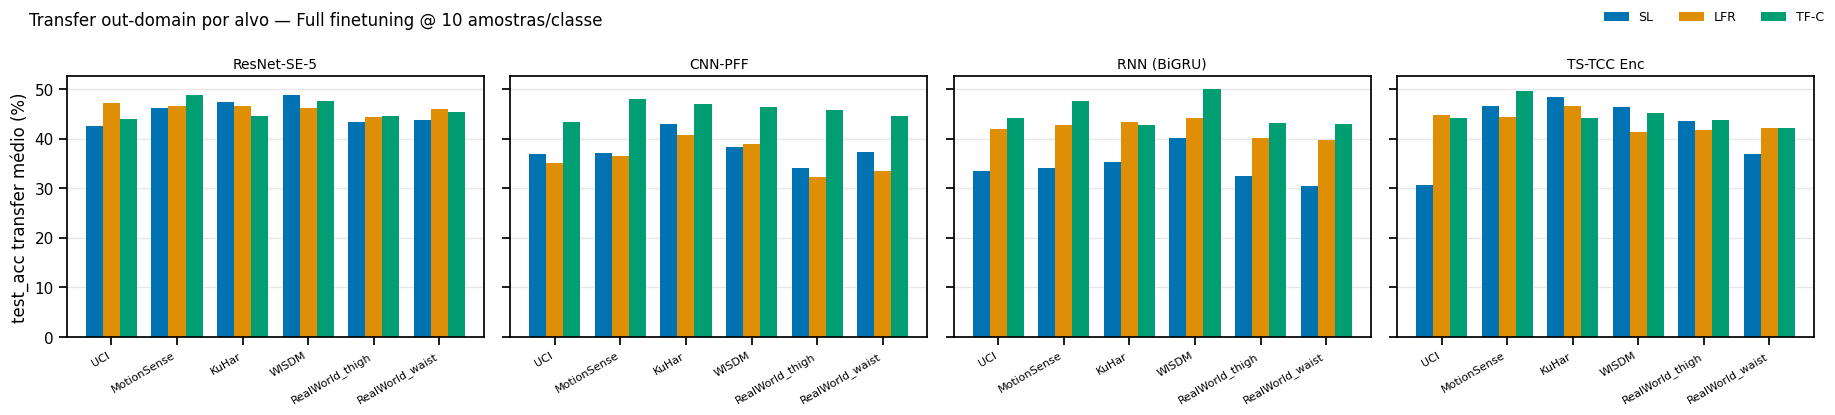

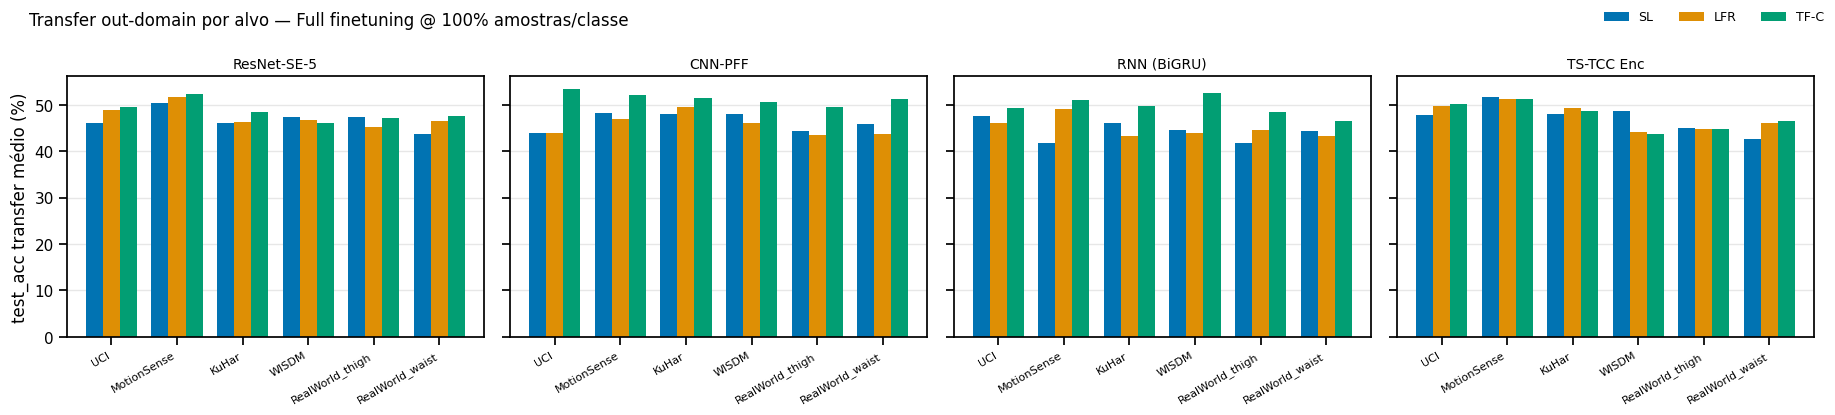

In [8]:
def transfer_bars(n_shots="10", protocol="finetune", metric="test_acc"):
    fig, axes = plt.subplots(1, len(ENCODERS), figsize=(4.6 * len(ENCODERS), 4.2),
                             sharey=True)
    series = [("SL", "sl"), ("LFR", protocol), ("TF-C", protocol)]
    width = 0.26
    x = np.arange(len(DATASETS))
    for c, encoder in enumerate(ENCODERS):
        ax = axes[c]
        for k, (method, proto) in enumerate(series):
            d = scenario_slice(df[(df.method == method) & (df.protocol == proto)
                                  & (df.encoder == encoder)
                                  & (df.n_shots == n_shots)], "transf")
            vals = [d[d.target == t][metric].mean() * 100 for t in DATASETS]
            ax.bar(x + (k - 1) * width, vals, width, color=METHOD_COLORS[method],
                   label=method if c == 0 else None)
        ax.set_title(ENCODER_PRETTY[encoder], fontsize=10)
        ax.set_xticks(x); ax.set_xticklabels(DATASETS, rotation=30, ha="right", fontsize=8)
        ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)
        if c == 0:
            ax.set_ylabel(f"{metric} transfer médio (%)")
    fig.legend(loc="upper right", ncols=3, fontsize=9, frameon=False)
    fig.suptitle(f"Transfer out-domain por alvo — {PROTOCOL_PRETTY[protocol]} @ "
                 f"{SHOT_LABELS.get(n_shots, n_shots)} amostras/classe",
                 x=0.02, ha="left", fontsize=12)
    plt.tight_layout(); plt.show()


transfer_bars("10")
transfer_bars("full")

## 8. Placar — melhor método por célula

Para cada célula (encoder × cenário × regime × alvo), qual série vence (na
média das seeds)? A tabela conta vitórias por série — um resumo grosseiro,
mas útil para ver dominâncias (empates contam para o maior valor).

In [9]:
def scoreboard(metric="test_acc"):
    rows = []
    for scen, _ in SCENARIOS:
        for encoder in ENCODERS:
            for shots in SHOT_ORDER:
                for t in DATASETS:
                    best_v, best_s = -1.0, None
                    for method, proto in SERIES:
                        d = scenario_slice(df[(df.method == method) & (df.protocol == proto)
                                              & (df.encoder == encoder)
                                              & (df.n_shots == shots)], scen)
                        v = d[d.target == t][metric].mean()
                        if pd.notna(v) and v > best_v:
                            best_v, best_s = v, _series_label(method, proto)
                    if best_s is not None:
                        rows.append({"cenário": SCENARIO_PRETTY[scen], "encoder": encoder,
                                     "regime": SHOT_LABELS[shots], "vencedor": best_s})
    t = pd.DataFrame(rows)
    if t.empty:
        print("Sem dados."); return
    display(t.pivot_table(index=["cenário", "regime"], columns="vencedor",
                          aggfunc="size", fill_value=0, sort=False))
    display(t.pivot_table(index="encoder", columns="vencedor",
                          aggfunc="size", fill_value=0))


scoreboard()

vencedor                                       LFR — Full finetuning  SL  \
cenário                                regime                              
Especialista (source == target)        1                           5   5   
                                       10                          2   3   
                                       100                         4   4   
                                       100%                        5   1   
Generalista (source = combinado)       1                           4   8   
                                       10                          4   3   
                                       100                         3   2   
                                       100%                        1   0   
Transfer out-domain (outros -> target) 1                           5   4   
                                       10                          4   4   
                                       100                         3   2   
                                       100%                        1   2   

vencedor                                       TF-C — Full finetuning  \
cenário                                regime                           
Especialista (source == target)        1                           12   
                                       10                          19   
                                       100                         16   
                                       100%                        17   
Generalista (source = combinado)       1                           12   
                                       10                          17   
                                       100                         18   
                                       100%                        18   
Transfer out-domain (outros -> target) 1                           14   
                                       10                          16   
                                       100                         18   
                                       100%                        15   

vencedor                                       TF-C — Linear readout  \
cenário                                regime                          
Especialista (source == target)        1                           2   
                                       10                          0   
                                       100                         0   
                                       100%                        1   
Generalista (source = combinado)       1                           0   
                                       10                          0   
                                       100                         1   
                                       100%                        1   
Transfer out-domain (outros -> target) 1                           0   
                                       10                          0   
                                       100                         1   
                                       100%                        4   

vencedor                                       LFR — Linear readout  
cenário                                regime                        
Especialista (source == target)        1                          0  
                                       10                         0  
                                       100                        0  
                                       100%                       0  
Generalista (source = combinado)       1                          0  
                                       10                         0  
                                       100                        0  
                                       100%                       4  
Transfer out-domain (outros -> target) 1                          1  
                                       10                         0  
                                       100                     

vencedor,LFR — Full finetuning,LFR — Linear readout,SL,TF-C — Full finetuning,TF-C — Linear readout
encoder,,,,,
cnnpff,0,0,2,66,4
resnetse5,16,0,20,33,3
rnn,6,1,0,63,2
tstcc,19,6,16,30,1


## 9. Conclusões

*Grades LFR e TF-C completas nos 4 encoders (commitadas 2026-07-13).
F1-macro, média sobre seeds; Δ = SSL finetune − SL.*

- **LFR vs TF-C**: no protocolo **finetune** o TF-C domina o LFR em quase
  toda a grade — é mais forte nos 3 cenários e nos 4 regimes (ex.: combinado
  @full 74.4 vs 67.0; especialista @10-shot 68.0 vs 57.5; transfer @full
  40.6 vs 36.7). A exceção é o **linear readout**, onde o LFR vence
  (combinado @full 65.7 vs 63.0; @1-shot 19.7 vs 10.8): as representações
  LFR são mais linearmente separáveis, as do TF-C precisam de adaptação.
- **Por encoder**: o padrão few-shot do LFR (ganho só na RNN) **não** se
  repete: o TF-C ajuda CNN-PFF (+17 a +23 pp in-domain few-shot) e RNN
  (+18 a +32 pp), com TS-TCC ~neutro e ResNet-SE-5 negativa @1-shot
  (−16.8 pp) mas positiva de 10-shot em diante.
- **SSL vs SL**: com TF-C + finetune, o SSL domina o baseline SL em
  praticamente todos os regimes e cenários (inclusive @100%, onde o LFR só
  empatava) — o argumento "SSL só vale em few-shot" não se sustenta para
  o TF-C neste benchmark.
- **Escolha para o federado (Exp. 3)**: método **TF-C**, avaliação
  **finetune**. Encoder: CNN-PFF ou RNN maximizam o ganho do SSL; a
  ResNet-SE-5 é a mais forte em valor absoluto @full (empate técnico com
  CNN-PFF), mas o diferencial do pré-treino é menor. Recomendação: rodar o
  FedSSL primeiro com TF-C × {CNN-PFF, RNN}, LFR como ablação.